In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The goal of this analysis is to explore Netflix's content dataset to understand trends in content production, distribution, and audience preferences across different countries, genres, and time periods.

In [59]:
df=pd.read_csv("netflix_titles.csv")
#keep raw data
df_raw = df.copy()
#create working copy
df = df_raw.copy()

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
df.shape

(8807, 12)

In [10]:
df.info()
# convert data added to date data type 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### data cleaning

In [56]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [66]:
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['date_added']=df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']=df['rating'].fillna('Unknown')

In [92]:
mask=df['rating'].str.contains("min",na=False)
df.loc[mask,'duration']=df.loc[mask,'rating']
df.loc[mask,'rating']='Unknown'

In [93]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
cast_count      0
dtype: int64

In [94]:
df['date_added']=pd.to_datetime(df['date_added'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  cast_count    8807 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(10)
memory usage: 894.6+ KB


In [95]:
df.duplicated().any()

np.False_

In [96]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",19
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",10
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,7
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",9


In [89]:
#feature creation
df['cast_count']=df['cast'].apply(lambda x :len(x.split(',')) if x !='Unknown' else 0)

In [99]:
def rating_category(x):
    if x in ['G', 'PG', 'TV-G', 'TV-Y', 'TV-Y7', 'TV-Y7-FV']:
        return 'Kids'
    elif x in ['PG-13', 'TV-PG', 'TV-14']:
        return 'Teens'
    elif x in ['R', 'NC-17', 'TV-MA']:
        return 'Adults'
    elif x in ['NR', 'UR']:
        return 'Unrated'
    else:
        return 'Unknown'

df['rating_category']=df['rating'].apply(rating_category)

In [101]:
df['rating_category'].unique()

array(['Teens', 'Adults', 'Kids', 'Unknown', 'Unrated'], dtype=object)

In [104]:
df['duration_int']=df['duration'].str.extract('(\d+)').astype(int)
df['seasons']=None
df.loc[df['type']=='TV Show','seasons']=df.loc[df['type']=='TV Show','duration_int']
df['movie_duration']=None
df.loc[df['type']=='Movie','movie_duration']=df.loc[df['type']=='Movie','duration_int']

In [109]:
df['primary_genre']=df['listed_in'].str.split(',').str[0]
#Each title may belong to multiple genres, but for simplicity, only the primary genre was considered.

In [112]:
#feature deletion 
df=df.drop('description',axis=1)
#The 'description' column contains unstructured text data which is not relevant for this analysis. Therefore, it was removed to simplify the dataset.


KeyError: "['description'] not found in axis"

In [114]:
df=df.drop(['cast','duration_int'], axis=1)

In [115]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,cast_count,rating_category,seasons,movie_duration,primary_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,0,Teens,None,90,Documentaries
1,s2,TV Show,Blood & Water,Unknown,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",19,Adults,2,None,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",9,Adults,1,None,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",0,Adults,1,None,Docuseries
4,s5,TV Show,Kota Factory,Unknown,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",8,Adults,2,None,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers",10,Adults,None,158,Cult Movies
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",0,Kids,2,None,Kids' TV
8804,s8805,Movie,Zombieland,Ruben Fleischer,United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",7,Adults,None,88,Comedies
8805,s8806,Movie,Zoom,Peter Hewitt,United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies",9,Kids,None,88,Children & Family Movies


<Axes: xlabel='date_added'>

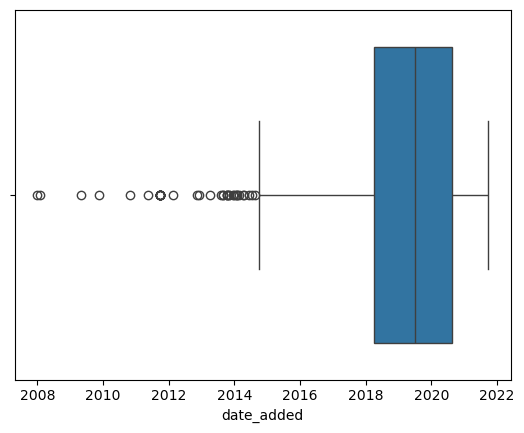

In [127]:
#outiers detection
sns.boxplot(x=df['date_added'])

<Axes: xlabel='release_year'>

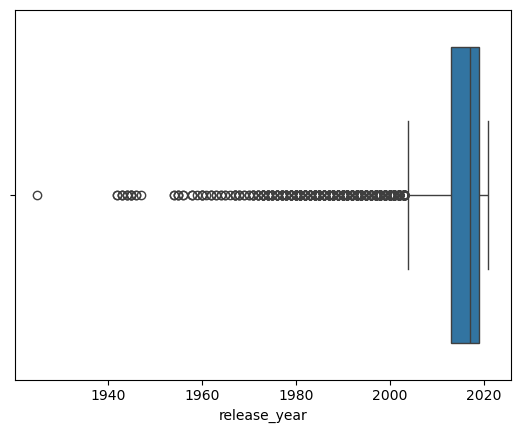

In [128]:
sns.boxplot(x=df['release_year'])

<Axes: xlabel='cast_count'>

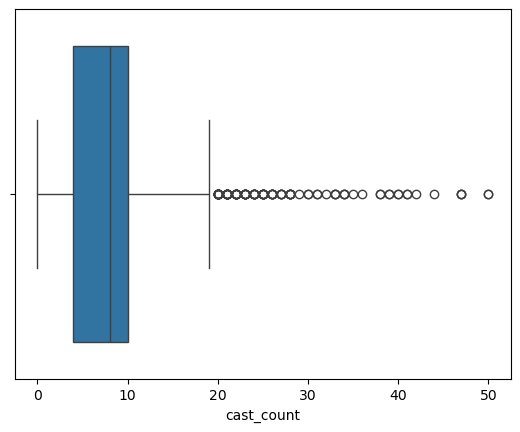

In [129]:
sns.boxplot(x=df['cast_count'])


<Axes: xlabel='seasons'>

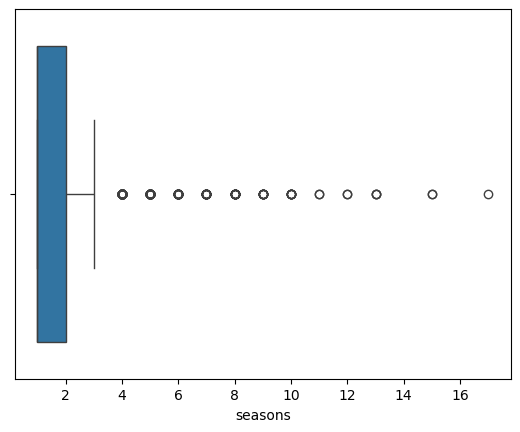

In [130]:
sns.boxplot(x=df['seasons'])

<Axes: xlabel='movie_duration'>

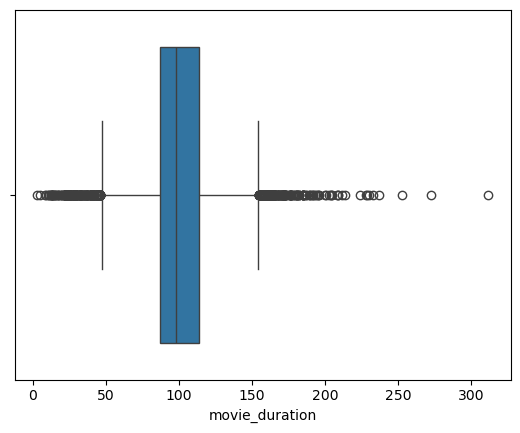

In [131]:
sns.boxplot(x=df['movie_duration'])

### EDA

In [134]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,cast_count,rating_category,seasons,movie_duration,primary_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,0,Teens,None,90,Documentaries
1,s2,TV Show,Blood & Water,Unknown,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",19,Adults,2,None,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",9,Adults,1,None,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",0,Adults,1,None,Docuseries
4,s5,TV Show,Kota Factory,Unknown,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",8,Adults,2,None,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers",10,Adults,None,158,Cult Movies
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",0,Kids,2,None,Kids' TV
8804,s8805,Movie,Zombieland,Ruben Fleischer,United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",7,Adults,None,88,Comedies
8805,s8806,Movie,Zoom,Peter Hewitt,United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies",9,Kids,None,88,Children & Family Movies


<Axes: xlabel='type', ylabel='count'>

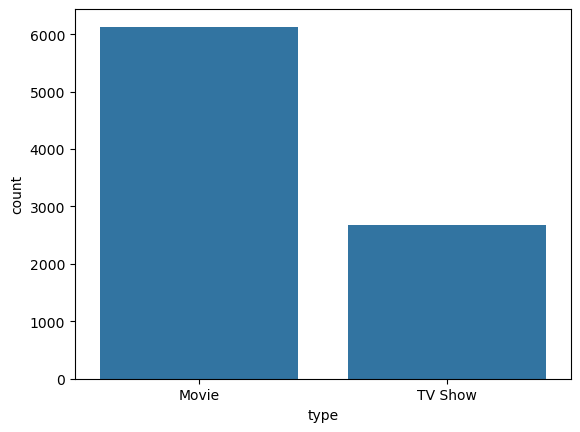

In [136]:
sns.countplot(x='type',data=df)
#significantly higher number of movies than TV shows

<Axes: xlabel='country'>

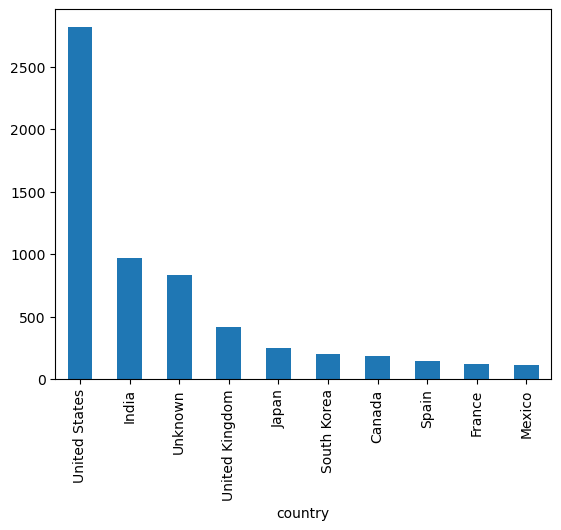

In [140]:
df['country'].value_counts().head(10).plot(kind='bar')
#US , India are high content producing nation while US is way ahead

<Axes: xlabel='date_added'>

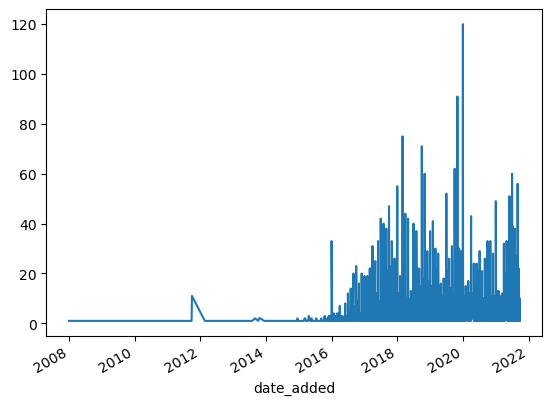

In [163]:
df['date_added'].value_counts().sort_index().plot(kind='line')
# most of content on netflix was added after 2018 and near 2020 there was sudden spike

<Axes: xlabel='primary_genre'>

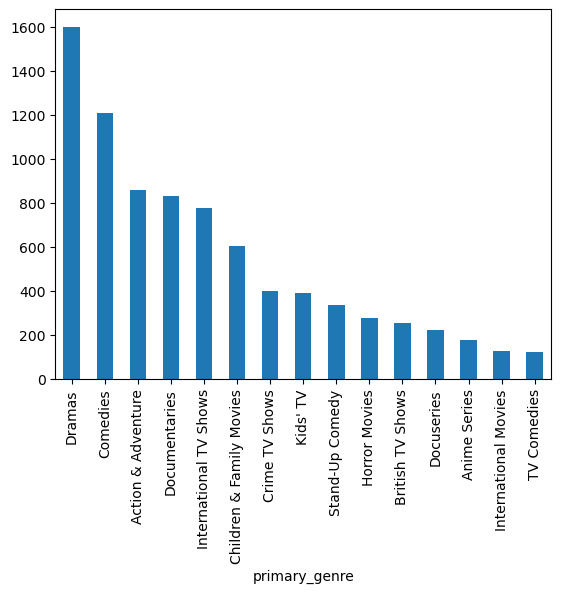

In [147]:
df['primary_genre'].value_counts().head(15).plot(kind='bar')
# Dramas, comedies are highly produced on netflix based on primary genre

<Axes: xlabel='rating_category', ylabel='count'>

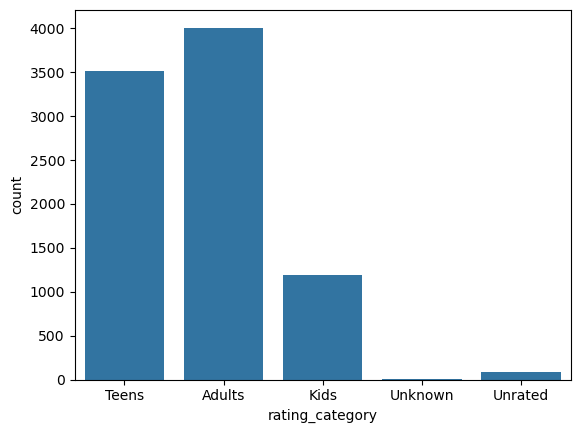

In [149]:
sns.countplot(x='rating_category',data=df)
#netflix is more focused on adult content followed by teens 

<Axes: xlabel='movie_duration', ylabel='Count'>

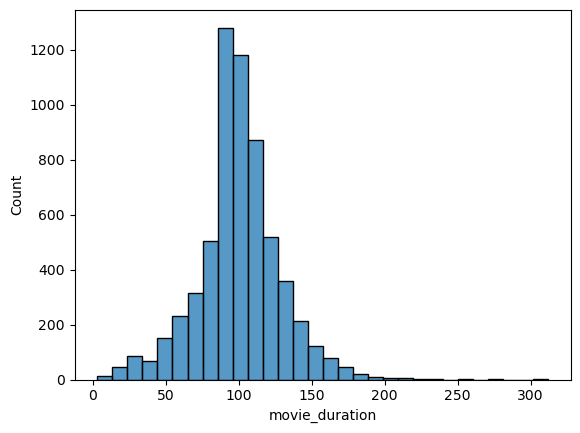

In [160]:
sns.histplot(df['movie_duration'].dropna(),bins=30)
# most of the movies on netlix are about 100 minutes long and most of TV shows have season 1 or 2

<Axes: xlabel='seasons', ylabel='Count'>

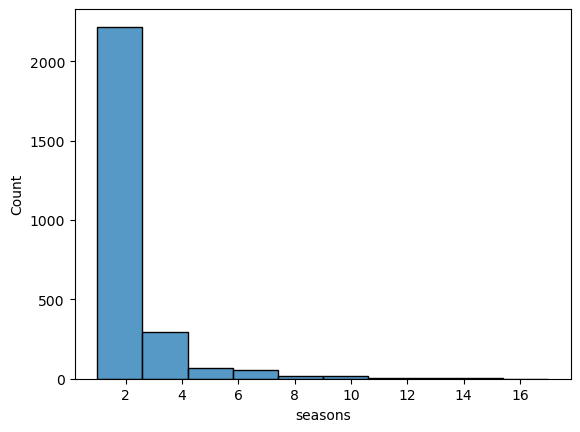

In [161]:
sns.histplot(df['seasons'].dropna(),bins=10)

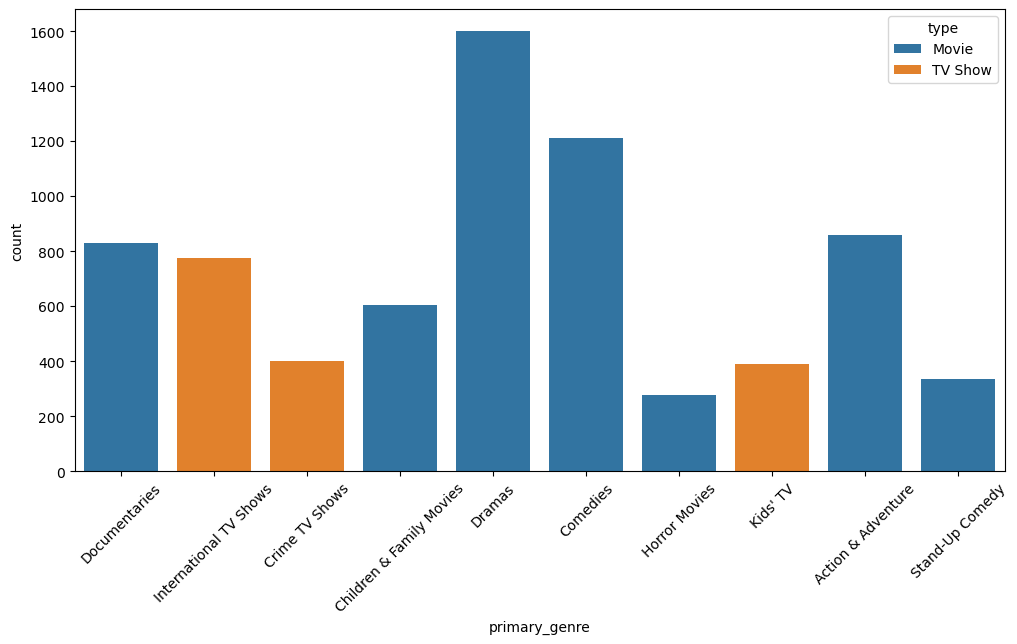

In [182]:
top_genres = df['primary_genre'].value_counts().head(10).index
tg=df[df['primary_genre'].isin(top_genres)]
plt.figure(figsize=(12,6))

sns.countplot(
    x='primary_genre',
    hue='type',
    data=tg
)
plt.xticks(rotation=45)
plt.show()

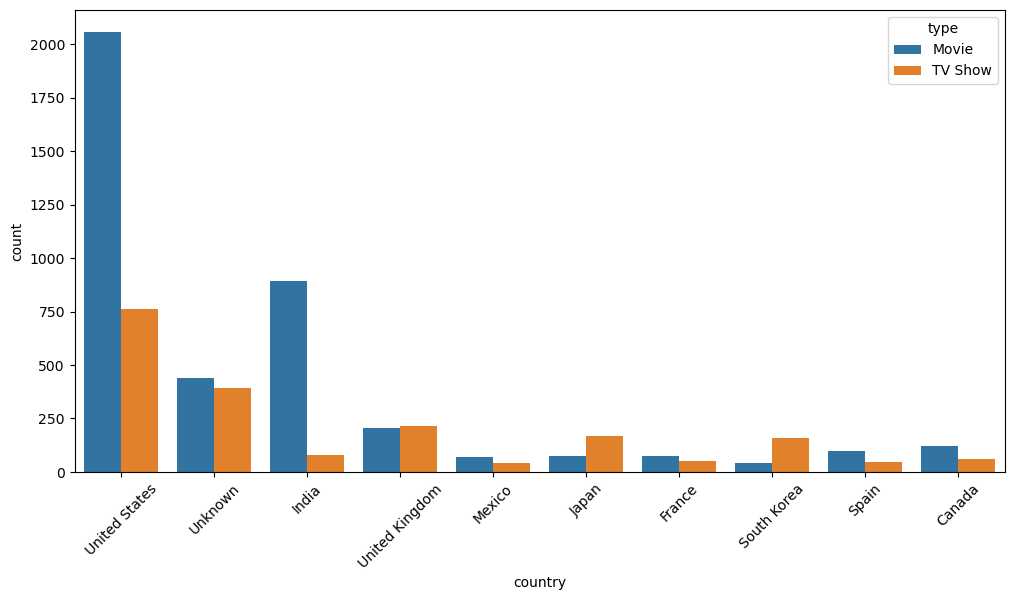

In [181]:
top_countries = df['country'].value_counts().head(10).index
top_country=df[df['country'].isin(top_countries)]
plt.figure(figsize=(12,6))
sns.countplot(x='country', hue='type', data=top_country)
plt.xticks(rotation=45)
plt.show()
#in most countries movies highly dominate than the tv shows

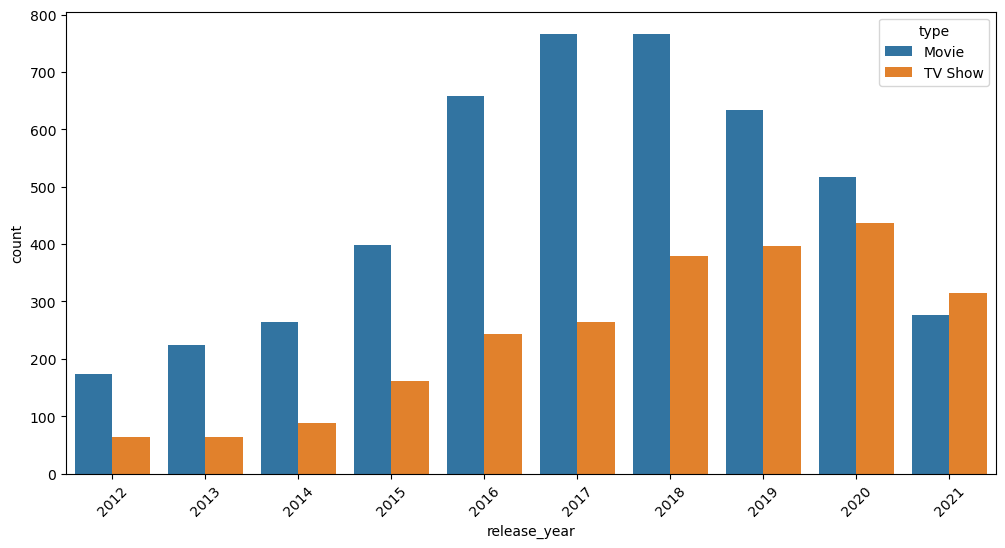

In [189]:
year = df['release_year'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.countplot(x='release_year', hue='type', data=df[df['release_year'].isin(year)])
plt.xticks(rotation=45)
plt.show()
# number of movies released increased till 2018 then gradually declined and number of TV shows realeased were more in 2021 as compared to movies

# Insights
1. Netflix has a significantly higher number of movies compared to TV shows, indicating a stronger focus on movie content.

2. The United States is the leading producer of content on Netflix, followed by India, highlighting the dominance of these regions in content creation.

3. A substantial increase in content addition is observed after 2018, with a peak around 2020, suggesting rapid platform expansion during this period.

4. Drama and Comedy are the most dominant genres on Netflix, indicating a strong preference for storytelling and entertainment-driven content.

5. Netflix primarily targets adult audiences, followed by teenagers, as seen from the distribution of content ratings.

6. Most movies on Netflix have a duration of around 90–120 minutes, indicating a standard movie length preference.

7. The majority of TV shows consist of 1–2 seasons, suggesting a focus on shorter series formats.

8. Across most countries, movies significantly outnumber TV shows, reinforcing Netflix’s movie-heavy content strategy.

9. The number of movies increased steadily until around 2018 and then showed a decline, while TV shows saw increased production, especially around 2021, indicating a strategic shift toward series content.


# conclusion
The analysis of Netflix content reveals that the platform is heavily focused on movie production, with a significant contribution from countries like the United States and India. Content addition has grown rapidly, especially after 2018, with a notable spike around 2020, possibly due to increased demand for streaming services. Drama and Comedy dominate as the most popular genres, and the platform primarily targets adult audiences. Additionally, most movies follow a standard duration of 90–120 minutes, while TV shows are generally short, with 1–2 seasons. Overall, the trends indicate a shift in recent years toward increased production of TV shows alongside movies.